In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines, prunning
from models.gmp import GMP
from models.lstm import LSTM
from models.gru import GRU
from models.leann import LEANN
from models.rtdtnn import RTDTNN, TransformerEncoderBlock, PositionalEncoding
import matplotlib.pyplot as plt
import numpy as np
import torch

Load data from files and init acpr meter

In [46]:
M = 5

dataset_path = "datasets/Custom_dataset"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.cut_signals(M)
container.get_gained_signals()
print(f"gain: {container.gain}")

acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )



gain: 7.750391483306885


In [47]:
frame_length = 64
batch_size = 128
batch_size_eval = 2048

pa_train_loader, pa_val_loader, pa_input_norm, pa_target_norm = data_loader.build_dataloaders(container, 
                                                                                              frame_length=frame_length, 
                                                                                              batch_size=batch_size, 
                                                                                              batch_size_eval=batch_size_eval, 
                                                                                              arch="pa",
                                                                                              normalize_method=None)
dla_train_loader, dla_val_loader, dla_input_norm, dla_target_norm = data_loader.build_dataloaders(container, 
                                                                                                  frame_length=frame_length, 
                                                                                                  batch_size=batch_size, 
                                                                                                  batch_size_eval=batch_size_eval, 
                                                                                                  arch="dla",
                                                                                                  normalize_method=None)
ila_train_loader, ila_val_loader, ila_input_norm, ila_target_norm = data_loader.build_dataloaders(container, 
                                                                                                  frame_length=frame_length, 
                                                                                                  batch_size=batch_size, 
                                                                                                  batch_size_eval=batch_size_eval, 
                                                                                                  arch="ila",
                                                                                                  normalize_method=None)

criterion = metrics.compute_mse
metric_criterion = metrics.compute_nmse


In [66]:
import torch
import numpy as np
from models.base_model import BaseModel


class PartialFrozenLinear(torch.nn.Module):
    def __init__(self, in_features, out_features, freeze_ratio=0.5):
        super().__init__()

        self.weight = torch.nn.Parameter(torch.randn(out_features, in_features) * 0.02)

        mask = torch.rand(out_features, in_features)

        self.register_buffer("train_mask", (mask > freeze_ratio).float())

        # случайные фиксированные веса
        self.register_buffer("frozen_weight", torch.randn(out_features, in_features) * 0.02)

        self.bias = torch.nn.Parameter(torch.zeros(out_features))

    def forward(self, x):

        effective_weight = (self.train_mask * self.weight + (1 - self.train_mask) * self.frozen_weight)

        return torch.nn.functional.linear(x, effective_weight, self.bias)




class KPBasedModule(torch.nn.Module):
    def __init__(self,
                 M: int = 5):
        
        assert M % 2 == 1, "M must be odd"
        
        torch.nn.Module.__init__(self)
        
        self.M = M
        self.K= 5
        self._eps = 1e-10
        self.feature_dim = (self.M + 3 * self.K * self.K) * 2
        
        self.linear_re = torch.nn.Linear(in_features=2*self.M, out_features=self.K)
        self.linear_im = torch.nn.Linear(in_features=2*self.M, out_features=self.K)
        self.linear_abs1 = torch.nn.Linear(in_features=self.M, out_features=self.K)
        self.linear_abs2 = torch.nn.Linear(in_features=self.M, out_features=self.K)
        self.linear_abs3 = torch.nn.Linear(in_features=self.M, out_features=self.K)

        self.activation = torch.nn.Hardswish()
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)

    def get_feature_dim(self):
        return self.feature_dim
        
    def _build_memory(self, x):
        # x: (B, N, 2)
        half = self.M // 2

        x_re = x[..., 0]  # (B, N)
        x_im = x[..., 1]

        x_re = torch.cat([x_re[:, -half:], x_re, x_re[:, :half]], dim=1)
        x_im = torch.cat([x_im[:, -half:], x_im, x_im[:, :half]], dim=1)

        x_re_mem = x_re.unfold(1, self.M, 1)  # (B, N, M)
        x_im_mem = x_im.unfold(1, self.M, 1)

        return x_re_mem, x_im_mem
    
    def _split_features(self, x_re_mem, x_im_mem):
        x_concat = torch.cat([x_re_mem, x_im_mem], dim=-1)
        
        magnitude2 = x_re_mem**2 + x_im_mem**2
        x_abs1 = torch.sqrt(magnitude2 + self._eps)
        x_abs2 = magnitude2
        x_abs3 = x_abs1 * magnitude2
        
        return (x_concat, x_abs1, x_abs2, x_abs3)
       
    def linear_projection(self, x_concat, x_abs1, x_abs2, x_abs3):
        z_re = self.activation(self.linear_re(x_concat))
        z_im = self.activation(self.linear_im(x_concat))
        z_abs1 = self.activation(self.linear_abs1(x_abs1))
        z_abs2 = self.activation(self.linear_abs2(x_abs2))
        z_abs3 = self.activation(self.linear_abs3(x_abs3))
        
        return (z_re, z_im, z_abs1, z_abs2, z_abs3)
    
    def kron_product(self, a, b):
        """
        Kronecker product for batches
        a: (B, N, K)
        b: (B, N, K)
        returns: (B, N, K*K)
        """
        B, N, K = a.shape
        
        a_expanded = a.unsqueeze(-1)  # (B, N, K, 1)
        b_expanded = b.unsqueeze(-2)  # (B, N, 1, K)
        
        kron = a_expanded * b_expanded  # (B, N, K, K)
        kron = kron.reshape(B, N, K * K)  # (B, N, K*K)
        
        return kron

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x_re_mem, x_im_mem = self._build_memory(x)
        x_concat, x_abs1, x_abs2, x_abs3 = self._split_features(x_re_mem, x_im_mem)
        z_re, z_im, z_abs1, z_abs2, z_abs3 = self.linear_projection(x_concat, x_abs1, x_abs2, x_abs3)
        
        # p = 1: (z_1 + j*z_2) ⊗ z_abs1
        kron1_real = self.kron_product(z_re, z_abs1)
        kron1_imag = self.kron_product(z_im, z_abs1)
        
        # p = 2: (z_1 + j*z_2) ⊗ z_abs2
        kron2_real = self.kron_product(z_re, z_abs2)
        kron2_imag = self.kron_product(z_im, z_abs2)
        
        # p = 3: (z_1 + j*z_2) ⊗ z_abs3
        kron3_real = self.kron_product(z_re, z_abs3)
        kron3_imag = self.kron_product(z_im, z_abs3)
        
        real_parts = [
            x_re_mem,      # (B, N, M)
            kron1_real,    # (B, N, K*K)
            kron2_real,    # (B, N, K*K)
            kron3_real     # (B, N, K*K)
        ]
        
        imag_parts = [
            x_im_mem,      # (B, N, M)
            kron1_imag,    # (B, N, K*K)
            kron2_imag,    # (B, N, K*K)
            kron3_imag     # (B, N, K*K)
        ]
        
        real_concat = torch.cat(real_parts, dim=-1)  # (B, N, M + 3*K*K)
        imag_concat = torch.cat(imag_parts, dim=-1)  # (B, N, M + 3*K*K)
        
        # Собираем в один тензор с размерностью (B, N, total_features, 2)
        kp_features = torch.stack([real_concat, imag_concat], dim=-1)  # (B, N, total_features, 2)
        
        return kp_features

In [6]:
class KPLSTMCombined(BaseModel, torch.nn.Module):
    def __init__(self, 
                 M: int = 5,
                 hidden_size: int = 5, 
                 num_layers: int = 1, 
                 output_size: int = 2, 
                 bidirectional: bool = False, 
                 batch_first: bool = True,
                 bias: bool = False, 
                 model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        # KP-модуль
        self.kp_module = KPBasedModule(M=M)
        
        # Размерность после KP
        feature_dim = self.kp_module.get_feature_dim()
        
        # Используем вашу существующую LSTM (или ее параметры)
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.batch_first = batch_first
        self.bias = bias
        self.num_directions = 2 if bidirectional else 1

        # LSTM слой с новым input_size
        self.lstm = torch.nn.LSTM(input_size=feature_dim,
                                  hidden_size=hidden_size,
                                  num_layers=num_layers,
                                  bidirectional=bidirectional,
                                  batch_first=batch_first,
                                  bias=bias)
        
        self.fc_out = torch.nn.Linear(in_features=hidden_size * self.num_directions,
                                      out_features=output_size,
                                      bias=bias)
        
        # self.input_size = 2
        self.output_size = output_size
    
    @utils.complex_handler
    def forward(self, x, h_0=None, c_0=None):
        """
        x: [batch, seq_len, 2]
        """
        
        # KP-модуль
        kp_features = self.kp_module(x)  # [B, T, F, 2]
        x_lstm = kp_features
        
        B, T, F, C = kp_features.shape
        x_lstm = kp_features.reshape(B, T, F * C)
        
        # Стандартный LSTM forward
        if h_0 is None:
            h_0 = torch.zeros(self.num_directions * self.num_layers,
                              B, 
                              self.hidden_size)
        if c_0 is None:
            c_0 = torch.zeros(self.num_directions * self.num_layers,
                              B, 
                              self.hidden_size)
        
        lstm_out, (h_n, c_n) = self.lstm(x_lstm, (h_0, c_0))
        output = self.fc_out(lstm_out)
        
        return output
    
    def _get_filename(self):
        return (
            f"{self.model_name}_KPLSTM_"
            f"hs{self.hidden_size}_nl{self.num_layers}_"
            f"M{self.kp_module.M}_K{self.kp_module.K}_"
            f"bi{int(self.bidirectional)}.pt"
        )

In [7]:
class KPLEANNCombined(BaseModel, torch.nn.Module):
    def __init__(self, 
                 M: int, 
                 L2: int, 
                 L3: int,
                 K: int, 
                 L1: int = 2,
                 model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.M = M
        self.L2 = L2
        self.L3 = L3
        self.K = K
        self.L1 = L1
        
        # KP-модуль
        self.kp_module = KPBasedModule(M=M)
        
        self.leann = LEANN(M=M, L2=L2, L3=L3, L1=L1, K=K)
        
        # Размерность после KP
        feature_dim = self.kp_module.get_feature_dim()
        kp_dim = self.kp_module.kp_dim
        
        self.kp_projection = torch.nn.Linear(in_features=kp_dim, out_features=2*self.L1)
    
    @utils.complex_handler
    def forward(self, x):
        """
        x: [batch, seq_len, 2]
        """
        B = x.shape[0]
        print(f"x.shape: {x.shape}")
        
        # KP-модуль
        kp_features = self.kp_module(x)
        print(f"kp_features.shape: {kp_features.shape}")
        
        kp = kp_features.mean(dim=1)
        kp = kp.reshape(B, -1)

        u = self.kp_projection(kp)
        
        amplitude, phase = self.leann.vdm(u)
        v = self.leann.lea_1(amplitude)
        h = self.leann.lea_k(v)
        I, Q = self.leann.prb(h, phase)
        
        print("u:", u.shape)
        print("amplitude:", amplitude.shape)
        print("phase:", phase.shape)
        print("v:", v.shape)
        print("h:", h.shape)
        print("I:", I.shape)
        print("Q:", Q.shape)
        
        output = self.leann.row_sum(I, Q)

        return output
    
    def _get_filename(self):
        return (
            f"{self.model_name}_{self.class_name}_"
            f"M_{self.M}_L1_{self.L1}_"
            f"L2_{self.L2}_L3_{self.L3}_K_{self.K}.pt")

In [8]:
class KPRTDTNNCombined(BaseModel, torch.nn.Module):
    def __init__(self, 
                 M: int,
                 d_model: int = 6, 
                 n_heads: int = 2, 
                 d_ff: int = 10, 
                 n_fc: int = 8, 
                 num_blocks: int = 1, 
                 model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.M = M
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_ff = d_ff
        self.n_fc = n_fc
        self.num_blocks = num_blocks
        
        # KP-модуль
        self.kp_module = KPBasedModule(M=M)
        feature_dim = self.kp_module.get_feature_dim()
        self.kp_norm = torch.nn.LayerNorm(feature_dim)
        
        # reduced_dim = 4
        reduced_dim = feature_dim

        # self.kp_projection = torch.nn.Linear(feature_dim, reduced_dim)
        
        self.input_fc = torch.nn.Linear(reduced_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        self.encoders = torch.nn.ModuleList(
            [TransformerEncoderBlock(d_model, n_heads, d_ff) for _ in range(num_blocks)]
        )
        
        self.fc = torch.nn.Linear(d_model, n_fc)
        self.activation = torch.nn.Tanh()
        
        self.out = torch.nn.Linear(n_fc, 2)
        
        torch.nn.init.xavier_uniform_(self.out.weight)
        torch.nn.init.zeros_(self.out.bias)
        

    @utils.complex_handler
    def forward(self, x):
        """
        x: [batch, seq_len, 2]
        """
        
        # KP-модуль
        kp = self.kp_module(x)  # [B, T, F, 2]
        
        B, T, F, C = kp.shape
        kp = kp.reshape(B, T, F * C)
        
        # kp = self.kp_norm(kp)
        
        # kp = self.kp_projection(kp)

        y = self.input_fc(kp)
        
        # y = self.pos_encoder(y)

        for encoder in self.encoders:
            y = encoder(y)

        y = self.fc(y)
        y = self.activation(y)
        output = self.out(y)
        
        return output
    
    def _get_filename(self):
        return (
            f"{self.model_name}_{self.class_name}"
            f"_dmodel{self.d_model}_heads{self.n_heads}"
            f"_dff{self.d_ff}_nfc{self.n_fc}_M{self.M}_blocks{self.num_blocks}.pt"
            )

In [ ]:
# class KPGMPCombined(BaseModel, torch.nn.Module):
#     def __init__(self, 
#                  M: int,
#                  Ka: int, 
#                  La: int, 
#                  Kb: int, 
#                  Lb: int, 
#                  Mb: int, 
#                  Kc: int, 
#                  Lc: int, 
#                  Mc: int, 
#                  model_name: str = ""):
        
#         torch.nn.Module.__init__(self)
#         BaseModel.__init__(self, model_name=model_name)
        
#         self.gmp = GMP(Ka, La, Kb, Lb, Mb, Kc, Lc, Mc,)
        
#         self.M = M
#         self.Ka, self.La = Ka, La
#         self.Kb, self.Lb, self.Mb = Kb, Lb, Mb
#         self.Kc, self.Lc, self.Mc = Kc, Lc, Mc
        
#         # KP-модуль
#         self.kp_module = KPBasedModule(M=M)
#         feature_dim = self.kp_module.get_feature_dim()
        
#         # reduced_dim = 4
#         reduced_dim = feature_dim

#         # self.kp_projection = torch.nn.Linear(feature_dim, reduced_dim)
        
#         # self.in_norm = torch.nn.LayerNorm(reduced_dim)
        

#     @utils.complex_handler
#     def forward(self, x):
#         """
#         x: [batch, seq_len, 2]
#         """
        
#         # KP-модуль
#         kp_features = self.kp_module(x)  # [B, T, F, 2]
        
#         B, T, F, C = kp_features.shape
#         kp = kp_features.reshape(B, T, F * C)
        
        
#         # kp = self.kp_projection(kp)
        
#         output = self.gmp(kp)
        
#         return output
    
#     def _get_filename(self):
#         return (f"{self.model_name}_{self.class_name}_"
#                 f"Ka{self.Ka}_La{self.La}_"
#                 f"Kb{self.Kb}_Lb{self.Lb}_Mb{self.Mb}_"
#                 f"Kc{self.Kc}_Lc{self.Lc}_Mc{self.Mc}.pt")

In [ ]:

class CausalConv1d(torch.nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 dilation):

        super().__init__()

        self.padding = (kernel_size - 1) * dilation

        self.conv = torch.nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation
        )

    def forward(self, x):

        out = self.conv(x)

        if self.padding != 0:
            out = out[:, :, :-self.padding]

        return out


class ResidualTCNBlock(torch.nn.Module):

    def __init__(self,
                 channels,
                 kernel_size=3,
                 dilation=1,
                 dropout=0.1):

        super().__init__()

        self.conv1 = CausalConv1d(channels, channels, kernel_size, dilation)

        self.conv2 = CausalConv1d(channels, channels, kernel_size, dilation)

        self.activation = torch.nn.ReLU()

        self.dropout = torch.nn.Dropout(dropout)

        self.norm1 = torch.nn.BatchNorm1d(channels)
        self.norm2 = torch.nn.BatchNorm1d(channels)

    def forward(self, x):

        residual = x

        out = self.conv1(x)
        out = self.norm1(out)
        out = self.activation(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.norm2(out)
        out = self.activation(out)

        out = out + residual

        return out


class TCN(BaseModel, torch.nn.Module):
    def __init__(self, 
                 in_channels: int = 2,
                 hidden_channels: int = 32,
                 out_channels: int = 2,
                 kernel_size: int = 5,
                 model_name: str = ""):
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.dilation = 1
        self.stride = 1

        pad1 = (kernel_size - 1) * self.dilation * 1
        pad2 = (kernel_size - 1) * self.dilation * 2
        pad3 = (kernel_size - 1) * self.dilation * 4
        pad4 = (kernel_size - 1) * self.dilation * 8

        
        self.network = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=self.in_channels, 
                            out_channels=self.hidden_channels, 
                            kernel_size=1),
            torch.nn.Hardswish(),
            torch.nn.Conv1d(self.hidden_channels, 
                            self.hidden_channels, 
                            self.kernel_size, 
                            stride=self.stride, 
                            padding=pad1, 
                            dilation=self.dilation, 
                            groups=self.hidden_channels, 
                            bias=False),
            torch.nn.Hardswish(),
            torch.nn.Conv1d(self.hidden_channels, 
                            self.hidden_channels, 
                            self.kernel_size, 
                            stride=self.stride, 
                            padding=pad2, 
                            dilation=self.dilation*2, 
                            groups=self.hidden_channels, 
                            bias=False),
            torch.nn.Hardswish(),
            torch.nn.Conv1d(self.hidden_channels, 
                            self.hidden_channels, 
                            self.kernel_size, 
                            stride=self.stride, 
                            padding=pad3, 
                            dilation=self.dilation*4, 
                            groups=self.hidden_channels, 
                            bias=False),
            torch.nn.Hardswish(),
            torch.nn.Conv1d(self.hidden_channels, 
                            self.hidden_channels, 
                            self.kernel_size, 
                            stride=self.stride,
                            padding=pad4, 
                            dilation=self.dilation*8, 
                            groups=self.hidden_channels, 
                            bias=False),
            torch.nn.Hardswish(),
            torch.nn.Conv1d(self.hidden_channels, 
                            self.out_channels, 
                            kernel_size=1, 
                            bias=False),
            )
        
        if in_channels != out_channels:
            self.residual_proj = torch.nn.Conv1d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_proj = torch.nn.Identity()
    
    def forward(self, x):

        x_transpose = x.transpose(1, 2)
        out = self.network(x_transpose)
        out = out[:, :, :x_transpose.shape[2]]
        
        res = self.residual_proj(x_transpose)
        res = res[:, :, :out.shape[2]]
        out = out + res
        
        out = out.transpose(1, 2)
        
        return out
    
    def _get_filename(self):
        return (
            f"{self.model_name}_{self.class_name}_"
            f"ic{self.in_channels}_hc{self.hidden_channels}_"
            f"oc{self.out_channels}_ks{self.kernel_size}.pt"
        )



class KPTCN(BaseModel, torch.nn.Module):
    def __init__(self,
                 M: int,
                 in_channels: int = 2,
                 hidden_channels: int = 32,
                 out_channels: int = 2,
                 kernel_size: int = 5,
                 model_name: str = ""):
        
        torch.nn.Module.__init__(self)
        BaseModel.__init__(self, model_name=model_name)
        
        self.M = M
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        
        self.memory_filter = torch.nn.Conv1d(in_channels=self.in_channels,
                                             out_channels=self.in_channels,
                                             kernel_size=5,
                                             padding=2,
                                             groups=1)
        
        self.kp_module = KPBasedModule(M=M)
        feature_dim = self.kp_module.get_feature_dim()
        reduced_dim = 4
        
        self.kp_gate = torch.nn.Parameter(torch.zeros(feature_dim))

        self.norm = torch.nn.LayerNorm(feature_dim)
        
        self.kp_proj = torch.nn.Conv1d(feature_dim, reduced_dim, kernel_size=1)

        self.tcn = TCN(in_channels=reduced_dim,
                       hidden_channels=hidden_channels,
                       out_channels=out_channels,
                       kernel_size=kernel_size,
                       model_name=model_name)
        
        self.refine = torch.nn.Sequential(
            torch.nn.Conv1d(self.out_channels, 8, kernel_size=3, padding=1),
            torch.nn.Hardswish(),
            torch.nn.Conv1d(8, self.out_channels, kernel_size=1)
        )

    @utils.complex_handler
    def forward(self, x):
        """
        x: [batch, seq_len, 2]
        """
        
        x_t = x.transpose(1, 2)      # [B,2,T]
        x_t = self.memory_filter(x_t)
        x = x_t.transpose(1, 2)
        
        kp_features = self.kp_module(x)  # [B, T, F, 2]
        
        B, T, F, C = kp_features.shape
        kp = kp_features.reshape(B, T, F * C)
        kp = kp * self.kp_gate
        kp = self.norm(kp)
        
        kp = kp.transpose(1, 2)
        kp = self.kp_proj(kp)
        kp = kp.transpose(1, 2)
        
        out = self.tcn(kp)
        
        out_t = out.transpose(1,2)
        out_t = self.refine(out_t)
        out = out_t.transpose(1,2)
        
        return out
    
    def _get_filename(self):
        return (
            f"{self.model_name}_{self.class_name}_"
            f"M{self.M}_"
            f"ic{self.in_channels}_hc{self.hidden_channels}_"
            f"oc{self.out_channels}_ks{self.kernel_size}.pt"
        )




PA

In [49]:

pa_degree = 6
pa_config = params.make_gmp_params(
    Ka=pa_degree,
    La=pa_degree,
    Kb=pa_degree,
    Lb=pa_degree,
    Mb=pa_degree,
    Kc=pa_degree,
    Lc=pa_degree,
    Mc=pa_degree,
)

pa_model = GMP(**pa_config, model_name="pa")


print(f"total_params: {pa_model.count_params()}")

epochs = 100
lr = 0.01

optimizer = torch.optim.AdamW(pa_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not pa_model.load_weights():
      learning.train(net=pa_model, 
            criterion=criterion, 
            optimizer=optimizer, 
            train_loader=pa_train_loader, 
            val_loader=pa_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion,
            scheduler=scheduler)
      pa_model.save_weights()
utils.freeze_pa_model(pa_model)

y_val_pa = learning.net_inference(net=pa_model, x=container.val_input)
pa_nmse = metrics.compute_nmse(y_val_pa, container.val_output)
print(f"Model NMSE: {pa_nmse:.2f}")

total_params: 936
Model weights loaded from model_params/pa_GMP_Ka6_La6_Kb6_Lb6_Mb6_Kc6_Lc6_Mc6.pt
Model NMSE: -40.75


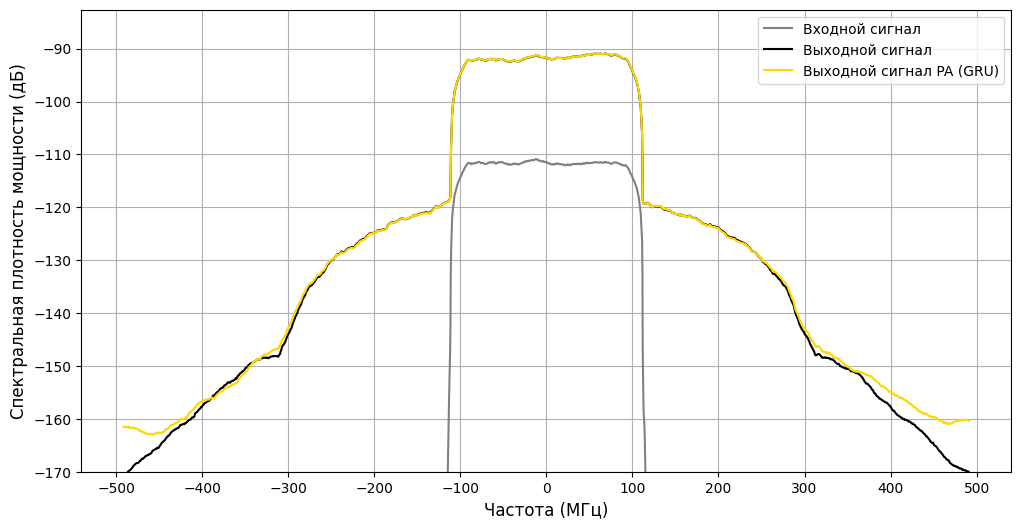

In [166]:
window_size = 50

freqs, spectrum_x_val = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_x_val, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val, color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_pa, color='gold', label='Выходной сигнал PA (GRU)')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.ylim(bottom=-170)
plt.xticks(np.arange(-500, 600, 100))
plt.grid()
plt.show()


ILC DPD

In [50]:
u_k_train = learning.ilc_signal(container.train_input, container.train_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_val = learning.ilc_signal(container.val_input, container.val_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

container.ilc_train_output = u_k_train
container.ilc_val_output = u_k_val



Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:46
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:29
NMSE на выходе усилителя (ILC): -70.27 db


In [51]:
# lstm

ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_dataloaders(container, 
                                                                            frame_length=frame_length,
                                                                            batch_size=batch_size, 
                                                                            batch_size_eval=batch_size_eval,
                                                                            arch="ilc",
                                                                            normalize_method='standard')

In [ ]:
# #leann

# ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                             batch_size=batch_size, 
#                                                                             batch_size_eval=batch_size_eval,
#                                                                             arch="ilc",
#                                                                             features_extractor=data_loader.build_LEANN_features,
#                                                                             normalize_method='standard',
#                                                                             M=M)

In [ ]:
# #rtdtnn

# ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                             batch_size=batch_size, 
#                                                                             batch_size_eval=batch_size_eval,
#                                                                             arch="ilc",
#                                                                             features_extractor=data_loader.build_RTDTNN_features,
#                                                                             normalize_method='standard',
#                                                                             M=M)

In [ ]:
L1 = 16
L2 = 8
L3 = 16
K = 3

epochs = 200
lr = 0.01
model_ilc = KPLEANNCombined(M=M, L2=L2, L3=L3, K=K, L1=L1, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

pa_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {pa_nmse:.2f}")

pa_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {pa_acpr[0]:.2f} {pa_acpr[1]:.2f}")

In [ ]:
epochs = 200
lr = 0.01
model_ilc = KPLSTMCombined(M=M, hidden_size=2, num_layers=1, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

In [ ]:
epochs = 200
lr = 0.01
model_ilc = KPRTDTNNCombined(M=M, 
                             d_model=10, 
                             n_heads=2, 
                             d_ff=10, 
                             n_fc=2,
                             num_blocks=2, 
                             model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

In [ ]:
epochs = 200
lr = 0.01
model_ilc = KPTCN(M=M, hidden_channels=24, kernel_size=4, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

total_params: 1982
Model weights loaded from model_params/ilc_KPTCNCombined_M5_ic2_hc24_oc2_ks4.pt
Model NMSE: -49.34
Model ACPR: -64.82 -62.76


In [73]:
epochs = 200
lr = 0.01
model_ilc = TCN(hidden_channels=54, kernel_size=8, model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")
is_load = model_ilc.load_weights()

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not is_load:
    learning.train(net=model_ilc, 
                criterion=criterion, 
                optimizer=optimizer, 
                train_loader=ilc_train_loader, 
                val_loader=ilc_val_loader, 
                n_epochs=epochs, 
                metric_criterion=metric_criterion,
                scheduler=scheduler)
    model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input)
x_val_in = norm_val_input

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {ilc_acpr[0]:.2f} {ilc_acpr[1]:.2f}")

total_params: 1998
Model weights loaded from model_params/ilc_TCN_ic2_hc54_oc2_ks8.pt
Model NMSE: -48.24
Model ACPR: -62.45 -62.39


In [75]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_target = metrics.power_spectrum(container.val_output_target, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_dpd_dla = metrics.power_spectrum(y_dpd_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ila = metrics.power_spectrum(y_dpd_ila, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ilc = metrics.power_spectrum(y_dpd_ilc, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_val_dla = metrics.power_spectrum(y_val_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_val_ila = metrics.power_spectrum(y_val_ila, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_ilc = metrics.power_spectrum(y_val_ilc, container.input_signal_fs, container.nperseg, window_size)


# _, spectrum_u_k = metrics.power_spectrum(u_k_val, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, container.input_signal_fs, container.nperseg, window_size)

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


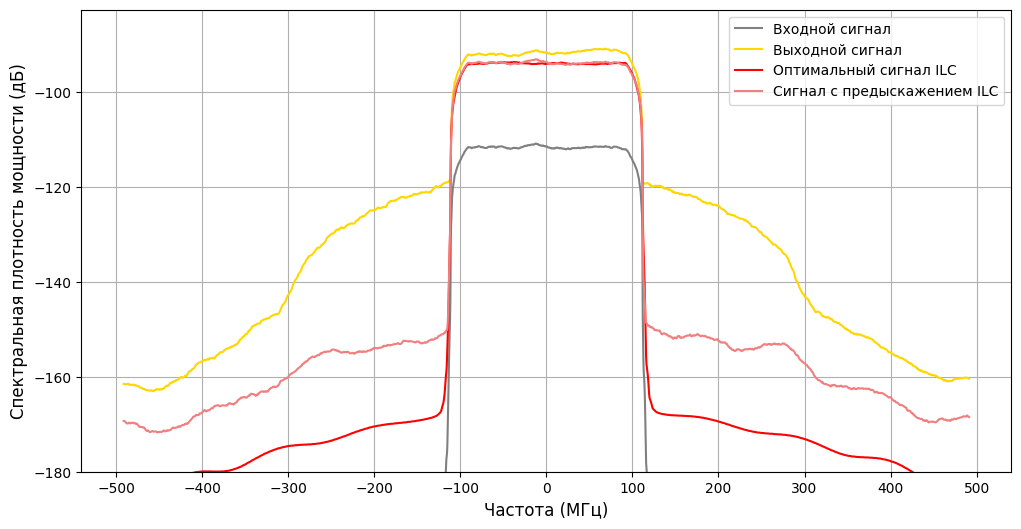

In [76]:
# построение спектра

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_u_k_pa, color='red', label='Оптимальный сигнал ILC')
# plt.plot(freqs / 1e6, spectrum_y_val_dla, color='darkorange', label='Сигнал с предыскажением DLA')
# plt.plot(freqs / 1e6, spectrum_y_val_ila, color='limegreen', label='Сигнал с предыскажением ILA')
plt.plot(freqs / 1e6, spectrum_y_val_ilc, color='lightcoral', label='Сигнал с предыскажением ILC')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.ylim(bottom=-180)
plt.grid()
plt.show()



Metrics

In [ ]:
nmse_after_pa = metrics.compute_nmse(y_val_pa, y_val_target)

print(f"NMSE на выходе усилителя (без DPD): {nmse_after_pa:.2f} db")
print(f"NMSE на выходе усилителя (DLA DPD): {gru_dla_nmse:.2f} db")
print(f"NMSE на выходе усилителя (ILA DPD): {gru_ila_nmse:.2f} db")
print(f"NMSE на выходе усилителя (ILC DPD): {gru_ilc_nmse:.2f} db")

NMSE на выходе усилителя (без DPD): -14.19 db
NMSE на выходе усилителя (DLA DPD): -41.53 db
NMSE на выходе усилителя (ILA DPD): -40.11 db
NMSE на выходе усилителя (ILC DPD): -42.04 db


In [ ]:
x_val_acpr = metrics.calculate_acpr(x_val, acpr_meter)
y_val_acpr = metrics.calculate_acpr(y_val, acpr_meter)
y_val_pa_acpr = metrics.calculate_acpr(y_val_pa, acpr_meter)
y_val_target_acpr = metrics.calculate_acpr(y_val_target, acpr_meter)

y_lin_dla_acpr = metrics.calculate_acpr(y_val_gru_dla, acpr_meter)
y_lin_ila_acpr = metrics.calculate_acpr(y_val_gru_ila, acpr_meter)
y_lin_ilc_acpr = metrics.calculate_acpr(y_val_gru_ilc, acpr_meter)

print(f"x_val_acpr: {x_val_acpr}")
print(f"y_val_acpr: {y_val_acpr}")
print(f"y_val_pa_acpr: {y_val_pa_acpr}")
print(f"y_val_target_acpr: {y_val_target_acpr}")

print(f"lin_dla_acpr: {y_lin_dla_acpr}")
print(f"lin_ila_acpr: {y_lin_ila_acpr}")
print(f"lin_ilc_acpr: {y_lin_ilc_acpr}")


x_val_acpr: [-48.08083195 -48.40122574]
y_val_acpr: [-40.60778184 -38.20237847]
y_val_pa_acpr: [-43.00702386 -41.82281169]
y_val_target_acpr: [-48.08083304 -48.40122404]
lin_dla_acpr: [-46.11408473 -46.21505539]
lin_ila_acpr: [-46.34155705 -46.7854869 ]
lin_ilc_acpr: [-45.85540157 -46.60117848]


In [ ]:
nmse_uk_pa = metrics.compute_nmse(u_k_pa, y_train_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

u_k_acpr = metrics.calculate_acpr(u_k_train, acpr_meter)
u_k_pa_acpr = metrics.calculate_acpr(u_k_pa, acpr_meter)

print(f"u_k_acpr: {u_k_acpr}")
print(f"u_k_pa_acpr: {u_k_pa_acpr}")

NMSE на выходе усилителя (ILC): -108.53 db
u_k_acpr: [-43.85630619 -43.42479372]
u_k_pa_acpr: [-50.93607041 -50.36966328]


Spectrum

In [ ]:
window_size = 60

freqs, spectrum_x_val = metrics.power_spectrum(x_val, fs, nperseg, window_size)
_, spectrum_y_val = metrics.power_spectrum(y_val, fs, nperseg, window_size)
_, spectrum_y_val_gru_pa = metrics.power_spectrum(y_val_pa, fs, nperseg, window_size)
_, spectrum_y_val_target = metrics.power_spectrum(y_val_target, fs, nperseg, window_size)

_, spectrum_y_val_gru_dla = metrics.power_spectrum(y_val_gru_dla, fs, nperseg, window_size)
_, spectrum_y_val_gru_ila = metrics.power_spectrum(y_val_gru_ila, fs, nperseg, window_size)
_, spectrum_y_val_gru_ilc = metrics.power_spectrum(y_val_gru_ilc, fs, nperseg, window_size)

_, spectrum_u_k = metrics.power_spectrum(u_k_train, fs, nperseg, window_size)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, fs, nperseg, window_size)

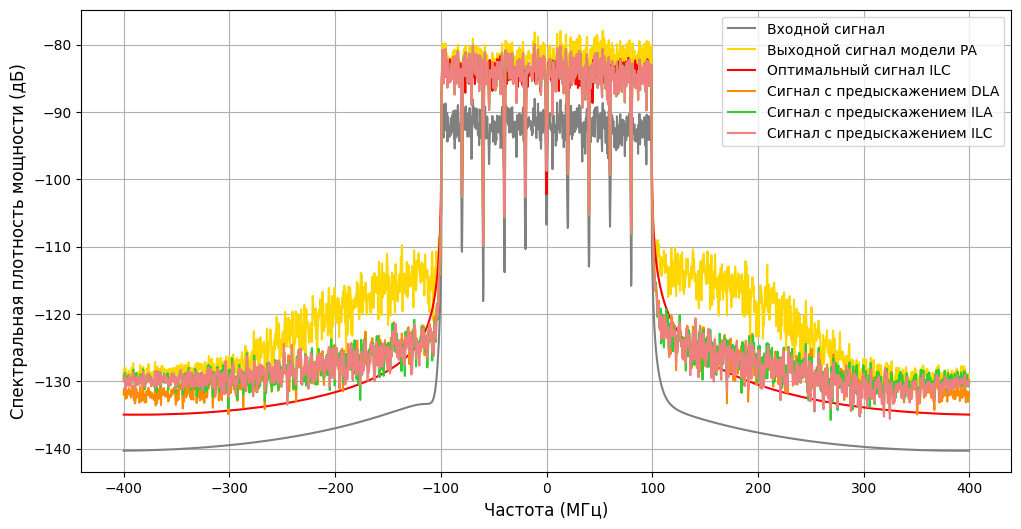

In [ ]:
# построение спектра

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_x_val, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val_gru_pa, color='gold', label='Выходной сигнал модели PA')
plt.plot(freqs / 1e6, spectrum_u_k_pa, color='red', label='Оптимальный сигнал ILC')
plt.plot(freqs / 1e6, spectrum_y_val_gru_dla, color='darkorange', label='Сигнал с предыскажением DLA')
plt.plot(freqs / 1e6, spectrum_y_val_gru_ila, color='limegreen', label='Сигнал с предыскажением ILA')
plt.plot(freqs / 1e6, spectrum_y_val_gru_ilc, color='lightcoral', label='Сигнал с предыскажением ILC')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()



In [ ]:
# moving_average
window_size = 100

freqs_s, spectrum_x_val_s = utils.moving_average(spectrum_x_val, freqs, fs, window_size)
_, spectrum_y_val_s = utils.moving_average(spectrum_y_val, freqs, fs, window_size)
_, spectrum_y_val_gru_pa_s = utils.moving_average(spectrum_y_val_gru_pa, freqs, fs, window_size)
_, spectrum_y_val_target_s = utils.moving_average(spectrum_y_val_target, freqs, fs, window_size)

# _, spectrum_y_val_gru_dla_s = utils.moving_average(spectrum_y_val_gru_dla, freqs, fs, window_size)
# _, spectrum_y_val_gru_ila_s = utils.moving_average(spectrum_y_val_gru_ila, freqs, fs, window_size)
# _, spectrum_y_val_gru_ilc_s = utils.moving_average(spectrum_y_val_gru_ilc, freqs, fs, window_size)

_, spectrum_y_val_gru_dla_s = utils.moving_average(spectrum_y_val_gru_dla, freqs, fs, window_size)
_, spectrum_y_val_gru_ila_s = utils.moving_average(spectrum_y_val_gru_ila, freqs, fs, window_size)
_, spectrum_y_val_gru_ilc_s = utils.moving_average(spectrum_y_val_gru_ilc, freqs, fs, window_size)

_, spectrum_u_k_s = utils.moving_average(spectrum_u_k, freqs, fs, window_size)
_, spectrum_u_k_pa_s = utils.moving_average(spectrum_u_k_pa, freqs, fs, window_size)



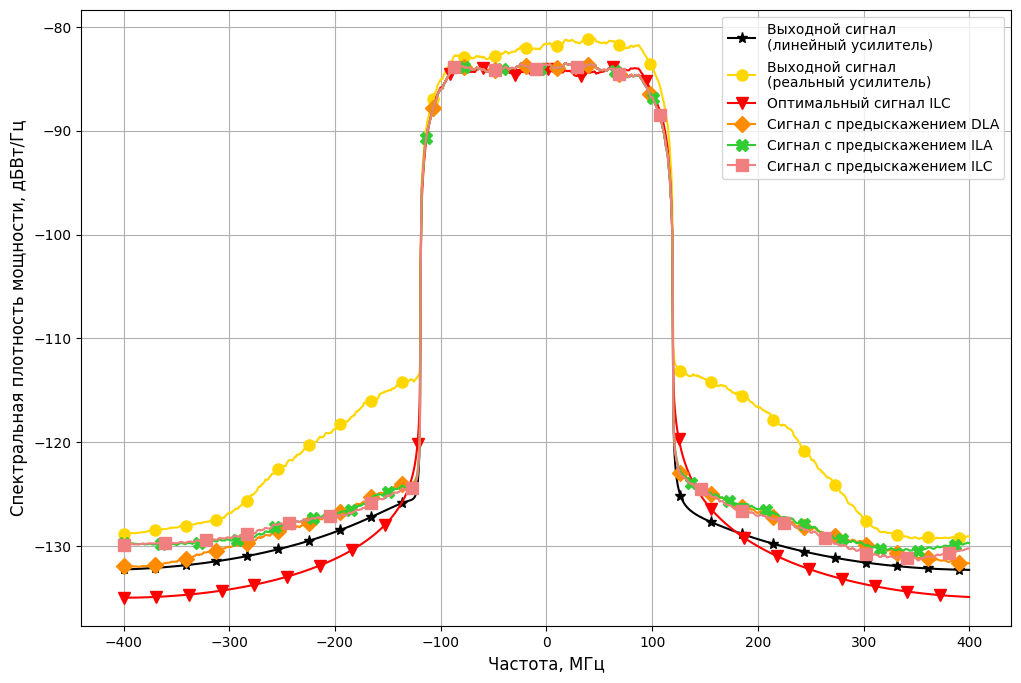

In [ ]:
# (сглаженный) построение спектра

xlabel="Частота, МГц"
ylabel= "Спектральная плотность мощности, дБВт/Гц"
fontsize = 12
figsize=(12, 8)
markersize=8

plt.figure(figsize=figsize)

# plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_x_val_s)), 
#          color='grey', label='Входной сигнал',marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_target_s)), 
         color='black', label='Выходной сигнал\n(линейный усилитель)',marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_pa_s)), 
         color='gold', label='Выходной сигнал\n(реальный усилитель)', marker='o', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_u_k_pa_s)), 
         color='red', label='Оптимальный сигнал ILC', marker='v', markevery=95, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_dla_s)), 
         color='darkorange', label='Сигнал с предыскажением DLA', marker='D', markevery=90, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_ila_s)), 
         color='limegreen', label='Сигнал с предыскажением ILA', marker='X', markevery=110, markersize=markersize)
plt.plot(freqs_s / 1e6, 10 * np.log10(np.abs(spectrum_y_val_gru_ilc_s)), 
         color='lightcoral', label='Сигнал с предыскажением ILC', marker='s', markevery=120, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.legend()
plt.grid()
plt.show()


AM/AM & AM/PM

In [ ]:
y_in_am_am, y_out_am_am = metrics.calculate_am_am(x_val, y_val)
y_in_am_pm, y_in_phase_am_pm = metrics.calculate_am_pm(x_val, y_val)

_, y_pa_am_am = metrics.calculate_am_am(x_val, y_val_gru_pa)
_, y_pa_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_pa)

_, y_val_target_am_am = metrics.calculate_am_am(x_val, y_val_target)
_, y_val_target_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_target)

# x_in_am_am, u_k_am_am = metrics.calculate_am_am(x_in_tensor, u_k)
# x_in_am_pm, u_k_phase_am_pm = metrics.calculate_am_pm(x_in_tensor, u_k)

# _, u_k_pa_am_am = metrics.calculate_am_am(x_in_tensor, u_k_pa)
# _, u_k_pa_phase_am_pm = metrics.calculate_am_pm(x_in_tensor, u_k_pa)

# dpd
# _, y_val_gru_dla_am_am = metrics.calculate_am_am(x_val, y_val_gru_dla)
# _, y_val_gru_dla_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_dla)

# _, y_val_gru_ila_am_am = metrics.calculate_am_am(x_val, y_val_gru_ila)
# _, y_val_gru_ila_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ila)

# _, y_val_gru_ilc_am_am = metrics.calculate_am_am(x_val, y_val_gru_ilc)
# _, y_val_gru_ilc_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ilc)

#linearized
_, y_val_gru_dla_am_am = metrics.calculate_am_am(x_val, y_val_gru_dla)
_, y_val_gru_dla_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_dla)

_, y_val_gru_ila_am_am = metrics.calculate_am_am(x_val, y_val_gru_ila)
_, y_val_gru_ila_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ila)

_, y_val_gru_ilc_am_am = metrics.calculate_am_am(x_val, y_val_gru_ilc)
_, y_val_gru_ilc_phase_am_pm = metrics.calculate_am_pm(x_val, y_val_gru_ilc)


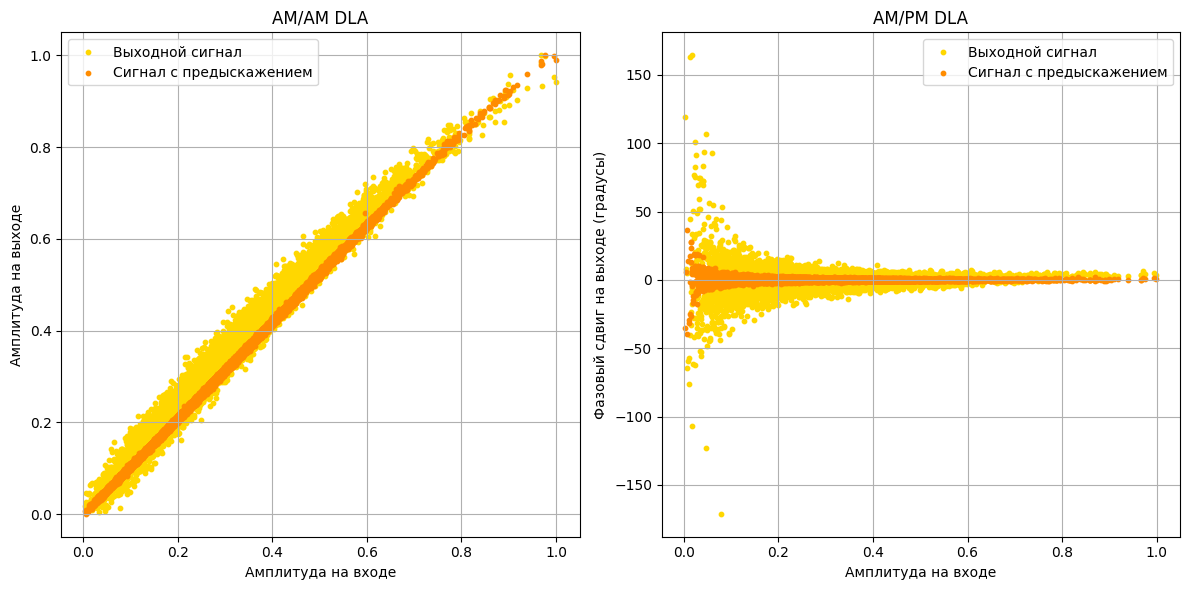

In [ ]:
#DLA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_gru_dla_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_val_gru_dla_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_gru_dla_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM DLA", "AM/PM DLA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)



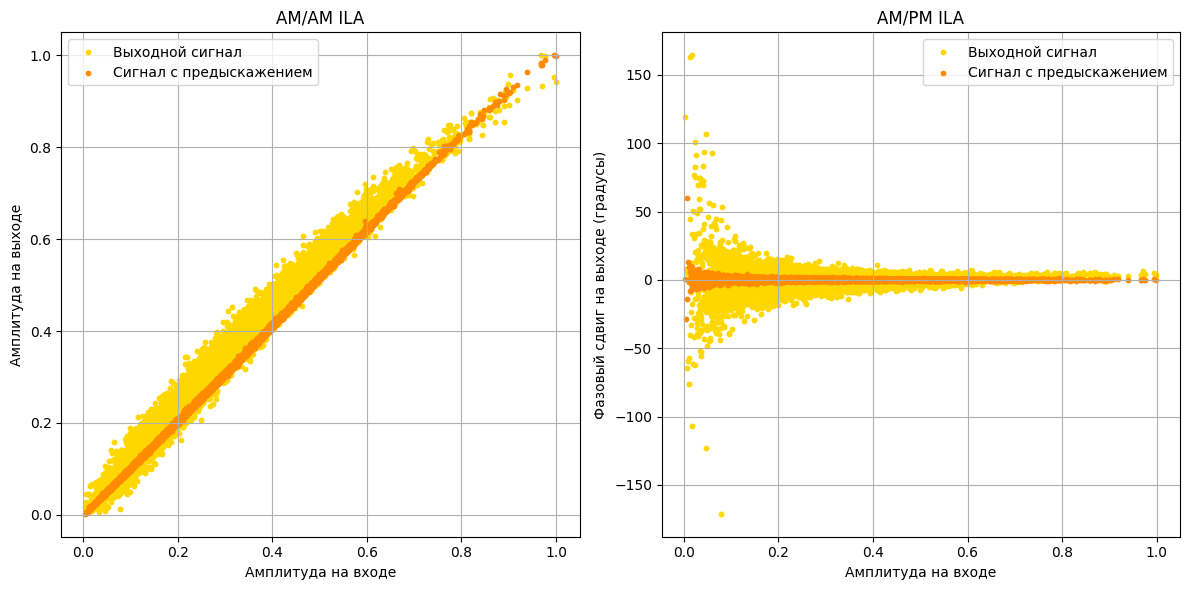

In [ ]:
#ILA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_gru_ila_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_val_gru_ila_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_gru_ila_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILA", "AM/PM ILA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


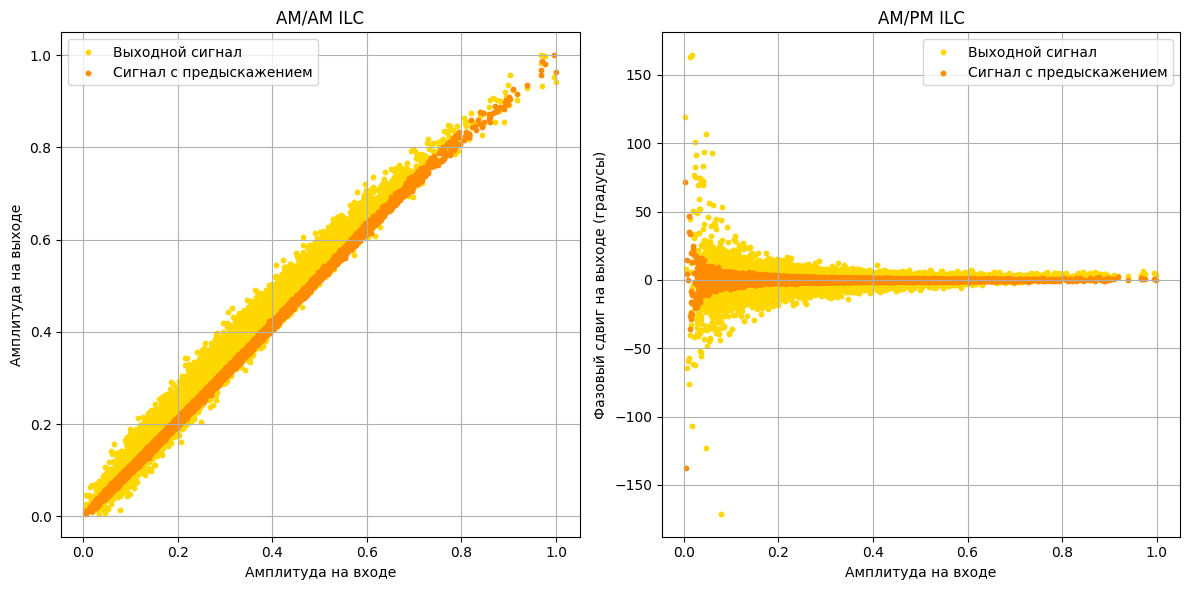

In [ ]:
#ILC

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_gru_ilc_am_am, 'magenta', 'Сигнал на выходе корректора'),
    (y_in_am_am, y_val_gru_ilc_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_gru_ilc_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILC", "AM/PM ILC"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


Add noise

In [ ]:

snr_range = list(range(20, 61, 5))

epochs = 100
lr = 0.001
num_realizations = 200

hidden_size=8
num_layers=1


snr_params = params.make_snr_params(
    snr_range=snr_range,
    num_realizations=num_realizations,
    fs=fs,
    bw_main_ch=bw_main_ch,
    epochs=epochs,
    learning_rate=lr,
    acpr_meter=acpr_meter,
    pa_model=gru_pa,
    gain=gain
)

nn_params = {
    "hidden_size": hidden_size,
    "num_layers": num_layers
}

snr_metrics_runner = pipelines.SnrPipeline(base_model=GRU, 
                                           input_model_params=nn_params, 
                                           data_dict=data, 
                                           snr_params=snr_params)

In [ ]:
snr_metrics_runner.run_dla_noise()

SNR: 20
===Start training===
Epoch 0000 — train_loss: 0.079289, val_loss: 0.016323, val_NMSE: -16.79
Epoch 0049 — train_loss: 0.014882, val_loss: 0.014754, val_NMSE: -17.23
Время обучения: 0:01:28
===Training complete===
SNR: 25
===Start training===
Epoch 0000 — train_loss: 0.098993, val_loss: 0.005751, val_NMSE: -21.32
Epoch 0049 — train_loss: 0.004938, val_loss: 0.005057, val_NMSE: -21.88
Время обучения: 0:01:29
===Training complete===
SNR: 30
===Start training===
Epoch 0000 — train_loss: 0.070503, val_loss: 0.002585, val_NMSE: -24.80
Epoch 0049 — train_loss: 0.001667, val_loss: 0.001624, val_NMSE: -26.82
Время обучения: 0:01:28
===Training complete===
SNR: 35
===Start training===
Epoch 0000 — train_loss: 0.103375, val_loss: 0.002465, val_NMSE: -25.00
Epoch 0049 — train_loss: 0.000583, val_loss: 0.000549, val_NMSE: -31.53
Время обучения: 0:01:27
===Training complete===
SNR: 40
===Start training===
Epoch 0000 — train_loss: 0.074668, val_loss: 0.001108, val_NMSE: -28.47
Epoch 0049 — tr

In [ ]:
snr_metrics_runner.run_ila_noise()

SNR: 20
===Start training===
Epoch 0000 — train_loss: 0.016766, val_loss: 0.002250, val_NMSE: -17.37
Epoch 0049 — train_loss: 0.001898, val_loss: 0.001839, val_NMSE: -18.24
Время обучения: 0:01:08
===Training complete===
SNR: 25
===Start training===
Epoch 0000 — train_loss: 0.014179, val_loss: 0.000916, val_NMSE: -21.27
Epoch 0049 — train_loss: 0.000684, val_loss: 0.000642, val_NMSE: -22.81
Время обучения: 0:01:08
===Training complete===
SNR: 30
===Start training===
Epoch 0000 — train_loss: 0.016422, val_loss: 0.000622, val_NMSE: -22.96
Epoch 0049 — train_loss: 0.000252, val_loss: 0.000237, val_NMSE: -27.15
Время обучения: 0:01:08
===Training complete===
SNR: 35
===Start training===
Epoch 0000 — train_loss: 0.020940, val_loss: 0.000851, val_NMSE: -21.59
Epoch 0049 — train_loss: 0.000104, val_loss: 0.000087, val_NMSE: -31.50
Время обучения: 0:01:08
===Training complete===
SNR: 40
===Start training===
Epoch 0000 — train_loss: 0.026843, val_loss: 0.000824, val_NMSE: -21.73
Epoch 0049 — tr

In [ ]:
snr_metrics_runner.run_ilc_noise()

SNR: 20
Epoch [0/200], Loss: 0.05504428967833519
Epoch [100/200], Loss: 0.0163440965116024
Epoch [199/200], Loss: 0.01662500575184822
Время расчёта ilc_signal: 0:12:49
===Start training===
Epoch 0000 — train_loss: 0.008179, val_loss: 0.072946, val_NMSE: 0.15
Epoch 0049 — train_loss: 0.000178, val_loss: 0.072638, val_NMSE: 0.13
Время обучения: 0:00:49
===Training complete===
SNR: 25
Epoch [0/200], Loss: 0.038476452231407166
Epoch [100/200], Loss: 0.005731415934860706
Epoch [199/200], Loss: 0.005766578484326601
Время расчёта ilc_signal: 0:12:47
===Start training===
Epoch 0000 — train_loss: 0.014055, val_loss: 0.075401, val_NMSE: 0.06
Epoch 0049 — train_loss: 0.000118, val_loss: 0.076817, val_NMSE: 0.14
Время обучения: 0:00:50
===Training complete===
SNR: 30
Epoch [0/200], Loss: 0.03320373594760895
Epoch [100/200], Loss: 0.0020090616308152676
Epoch [199/200], Loss: 0.002058345125988126
Время расчёта ilc_signal: 0:12:51
===Start training===
Epoch 0000 — train_loss: 0.011876, val_loss: 0.07

In [ ]:
results = snr_metrics_runner.get_results()

snr_range = results["snr_range"]

nmse_dla_list = results["dla"]["nmse"]
acpr_left_dla_list = results["dla"]["acpr_left"]
acpr_right_dla_list = results["dla"]["acpr_right"]

nmse_ila_list = results["ila"]["nmse"]
acpr_left_ila_list = results["ila"]["acpr_left"]
acpr_right_ila_list = results["ila"]["acpr_right"]

nmse_ilc_list = results["ilc"]["nmse"]
acpr_left_ilc_list = results["ilc"]["acpr_left"]
acpr_right_ilc_list = results["ilc"]["acpr_right"]

nmse_uk_list = results["uk"]["nmse"]
acpr_left_uk_list = results["uk"]["acpr_left"]
acpr_right_uk_list = results["uk"]["acpr_right"]

In [ ]:
print(f"snr_range = {snr_range}")
print()

print(f"nmse_dla_list = {(nmse_dla_list)}")
print(f"acpr_left_dla_list = {acpr_left_dla_list}")
print(f"acpr_right_dla_list = {acpr_right_dla_list}")
print()

print(f"nmse_ila_list = {nmse_ila_list}")
print(f"acpr_left_ila_list = {acpr_left_ila_list}")
print(f"acpr_right_ila_list = {acpr_right_ila_list}")
print()

print(f"nmse_ilc_list = {nmse_ilc_list}")
print(f"acpr_left_ilc_list = {acpr_left_ilc_list}")
print(f"acpr_right_ilc_list = {acpr_right_ilc_list}")
print()

print(f"nmse_uk_list = {nmse_uk_list}")
print(f"acpr_left_uk_list = {acpr_left_uk_list}")
print(f"acpr_right_uk_list = {acpr_right_uk_list}")

snr_range = [20, 25, 30, 35, 40, 45, 50, 55, 60]

nmse_dla_list = [-17.137060165405273, -21.96965980529785, -26.81765365600586, -31.505434036254883, -35.57054138183594, -38.63620376586914, -39.113792419433594, -38.6195068359375, -41.02045822143555]
acpr_left_dla_list = [np.float64(-20.043180907001865), np.float64(-24.997615366869727), np.float64(-29.88420059459173), np.float64(-34.69813351874072), np.float64(-39.11869853930988), np.float64(-42.75941617564841), np.float64(-44.556015439067544), np.float64(-45.50579331757665), np.float64(-45.856063390816914)]
acpr_right_dla_list = [np.float64(-20.03768970456767), np.float64(-24.98483819339822), np.float64(-29.91008171158717), np.float64(-34.66632986010521), np.float64(-39.092701210139325), np.float64(-42.551257239684695), np.float64(-44.15280496551297), np.float64(-45.29853879521245), np.float64(-46.00348917956039)]

nmse_ila_list = [-16.82413673400879, -21.81842613220215, -26.752714157104492, -31.452070236206055, -35.70893096923828, -34.

In [ ]:
# # значения в виде списков чтобы не рассчитывать снова все значения

# snr_range = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]

# nmse_dla_list = [-14.1044340133667, -16.018064498901367, -17.97743797302246, -19.84555435180664, -21.76476287841797, -23.601543426513672, -25.397140502929688, -27.051654815673828, -28.60270118713379, -29.951904296875, -31.10137939453125, -31.99922752380371, -32.693359375, -33.20136260986328, -33.556922912597656, -33.7752571105957, -33.94951248168945, -34.041229248046875, -34.11683654785156, -34.161094665527344, -34.18443298339844]
# acpr_left_dla_list = [-19.98307782854365, -22.044059761313314, -24.047040241882005, -25.981348959580895, -27.975370600038946, -29.942117343851447, -31.96514345661867, -33.80510011678665, -35.72137883607495, -37.63892721922215, -39.546686668811134, -41.14783435664147, -42.72300193647455, -44.1586403570728, -45.36636102368466, -46.3075550113637, -47.042928773938236, -47.62786795374185, -48.053632118082476, -48.26038054693791, -48.41887604347718]
# acpr_right_dla_list = [-20.041831052899113, -21.95478038014439, -23.98363774561688, -25.910596158467115, -27.91143197214374, -29.830851608311, -31.79363647332617, -33.5694401253062, -35.43604753655994, -37.07000947388168, -38.589720264578695, -39.981493718118756, -41.18240060456666, -42.0034433292463, -42.727465426518414, -43.28342016300996, -43.61496527628741, -43.81084719101566, -43.98201861121989, -44.08200476372817, -44.162913038570224]

# nmse_ila_list = [-13.854040145874023, -15.777467727661133, -17.762771606445312, -19.657350540161133, -21.58496856689453, -23.4307918548584, -25.17462730407715, -26.818567276000977, -28.340505599975586, -29.61135482788086, -30.697265625, -31.556087493896484, -32.22067642211914, -32.64470291137695, -32.968238830566406, -33.183040618896484, -33.31875991821289, -33.422943115234375, -33.47233963012695, -33.510684967041016, -33.5294189453125]
# acpr_left_ila_list = [-20.027768364406164, -22.02595135920506, -23.98453820660988, -25.961216816485567, -27.89464166886246, -29.93190200512903, -31.88604293318803, -33.82673998661604, -35.772038392214476, -37.61613725169961, -39.35554674161212, -40.999545012141596, -42.574679365583734, -43.93042452256015, -45.03867510014294, -45.908987401819914, -46.56702971768967, -47.03977254628908, -47.41264367177677, -47.67963051393086, -47.772995960135724]
# acpr_right_ila_list = [-19.930579122305584, -21.869039603483063, -23.92589430272745, -25.8934186825347, -27.89435768624694, -29.824054115245037, -31.657192539039386, -33.574507705349546, -35.29508665583067, -36.91289391444029, -38.35332621280914, -39.531460585547265, -40.53575407057057, -41.37233528658536, -41.93340984815785, -42.33601701225255, -42.63072372715388, -42.78626262772036, -42.906565042070014, -42.98986099019487, -43.06106380151427]

# nmse_ilc_list = [-14.0765962600708, -16.038497924804688, -17.95038604736328, -19.846113204956055, -21.75259017944336, -23.631811141967773, -25.368045806884766, -27.051647186279297, -28.601642608642578, -29.968273162841797, -31.0953426361084, -32.05195999145508, -32.759464263916016, -33.242897033691406, -33.58929443359375, -33.86418914794922, -34.00400924682617, -34.103553771972656, -34.197731018066406, -34.209129333496094, -34.251609802246094]
# acpr_left_ilc_list = [-19.987904634237463, -22.032664265763948, -23.981805945312637, -25.985078180439405, -27.97285318573928, -29.932254292413706, -31.93950622504634, -33.871982256476386, -35.687000986372624, -37.643129058194496, -39.36068479051006, -41.063457267103004, -42.61319314281078, -43.93533817262031, -45.077593707598375, -46.05866500876228, -46.68572673296391, -47.206334708000576, -47.541040851625766, -47.77248651232119, -47.95394808902196]
# acpr_right_ilc_list = [-19.970945068810845, -21.99232485637614, -23.99870022329292, -25.8777047238745, -27.85245425738548, -29.870087979042914, -31.71947716771799, -33.548264032512904, -35.38769115623252, -36.93997367595692, -38.44486643405877, -39.832029876134314, -40.894418612291034, -41.675168206028694, -42.37802985442333, -42.748574412828496, -43.07917614846056, -43.318133130296104, -43.473543736876735, -43.543050561279685, -43.59642567165372]

# nmse_uk_list = [-14.0831298828125, -16.007923126220703, -17.956777572631836, -19.8975887298584, -21.878353118896484, -23.844219207763672, -25.788644790649414, -27.7381649017334, -29.701080322265625, -31.64846420288086, -33.609657287597656, -35.53433609008789, -37.480770111083984, -39.428749084472656, -41.34610366821289, -43.275142669677734, -45.19207000732422, -47.10540771484375, -48.99323654174805, -50.86845397949219, -52.7203369140625]
# acpr_left_uk_list = [-19.998392505893012, -21.96503696465798, -23.970991167027375, -25.9149880083065, -27.92604114808463, -29.87986846158727, -31.819333935519474, -33.75500066095982, -35.68040463397734, -37.580494422986966, -39.43423352610119, -41.25160083392008, -42.91737743348149, -44.5111827081357, -45.92210941660184, -47.14031506566594, -48.14644265515601, -48.92050801676599, -49.54857485864436, -49.93755700347053, -50.273354378725]
# acpr_right_uk_list = [-19.893920065196465, -21.86624051842887, -23.84565607408318, -25.75388263544563, -27.70074723690906, -29.627564553190144, -31.569643994482238, -33.43726278691267, -35.32040951826972, -37.142184428452595, -38.9831850829623, -40.66346961805266, -42.32750364604643, -43.85724713876513, -45.296073869065694, -46.486982373361776, -47.48990958237207, -48.29148483835154, -48.9249656987649, -49.38223862798154, -49.67895177822955]

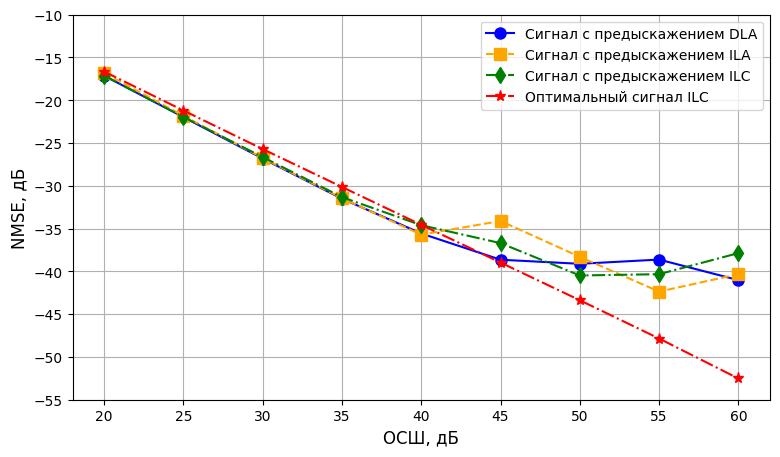

In [ ]:
markersize = 8
plt.figure(figsize=(9, 5))
plt.plot(snr_range, nmse_dla_list,color='blue', linestyle='-', label="Сигнал с предыскажением DLA",
         marker='o', markersize=markersize)
plt.plot(snr_range, nmse_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA",
         marker='s', markersize=markersize)
plt.plot(snr_range, nmse_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC",
         marker='d', markersize=markersize)
plt.plot(snr_range, nmse_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC",
         marker='*', markersize=markersize)

plt.xlabel("ОСШ, дБ", fontsize=12)
plt.ylabel("NMSE, дБ", fontsize=12)
# plt.title("Зависимость NMSE от ОСШ")
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -9, 5))
plt.legend()
plt.grid(True)

plt.show()


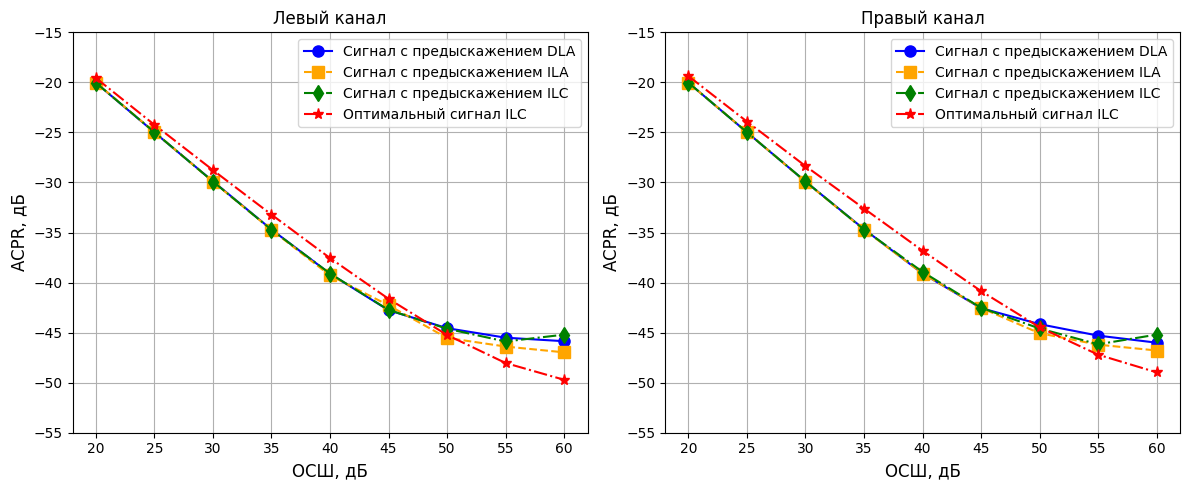

In [ ]:
markersize=8
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# plt.plot(snr_range, acpr_left_dla_list, marker='o', color='blue', linestyle='-', label="Сигнал с предыскажением DLA")
# plt.plot(snr_range, acpr_left_ila_list, marker='s', color='orange', linestyle='--', label="Сигнал с предыскажением ILA")
# plt.plot(snr_range, acpr_left_ilc_list, marker='d', color='green', linestyle='-.', label="Сигнал с предыскажением ILC")
# plt.plot(snr_range, acpr_left_uk_list, marker='*', color='indigo', linestyle='-.', label="Оптимальный сигнал ILC")
plt.plot(snr_range, acpr_left_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_left_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_left_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_left_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Левый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(snr_range, acpr_right_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_right_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_right_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_right_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Правый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()